# Projeto de Predição de Obesidade Fase 4

####1º Etapa
Este notebook contém a pipeline de Machine Learning para auxiliar o diagnóstico médico baseando-se em hábitos e dados fisiológicos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib



try:
    df = pd.read_csv('Obesity.csv')
    print('Dataset carregado com sucesso!')
    display(df.head())
except FileNotFoundError:
    print('Arquivo obesity.csv não encontrado. Por favor, faça o upload do arquivo na aba lateral.')

Dataset carregado com sucesso!


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Engenharia  e Pré-processamento
####2º Etapa
Conforme o dicionário, ajuste de base arredondamento as escalas numéricas e codificando as variáveis categóricas.

In [3]:
if 'df' in locals():
    # 1. Arredondamento de colunas com ruído decimal (conforme dicionário)
    cols_to_round = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
    for col in cols_to_round:
        if col in df.columns:
            df[col] = df[col].round().astype(int)

    # 2. Separação de Features (X) e Target (y)

    target_col = 'Obesity_level' if 'Obesity_level' in df.columns else 'Obesity'
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # 3. Encoding de variáveis categóricas
    le = LabelEncoder()

    # Codificando o Target
    y_encoded = le.fit_transform(y)

    # Codificando Features Categóricas
    categorical_cols = X.select_dtypes(include=['object']).columns
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    # 4. Divisão Treino e Teste
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

    print(f'Features preparadas: {X_encoded.shape[1]} colunas.')
    print(f'Classes mapeadas: {dict(enumerate(le.classes_))}')

Features preparadas: 23 colunas.
Classes mapeadas: {0: 'Insufficient_Weight', 1: 'Normal_Weight', 2: 'Obesity_Type_I', 3: 'Obesity_Type_II', 4: 'Obesity_Type_III', 5: 'Overweight_Level_I', 6: 'Overweight_Level_II'}


### Correlação entre Variáveis Numéricas
####3º Etapa
Vamos analisar como as variáveis contínuas se relacionam entre si.

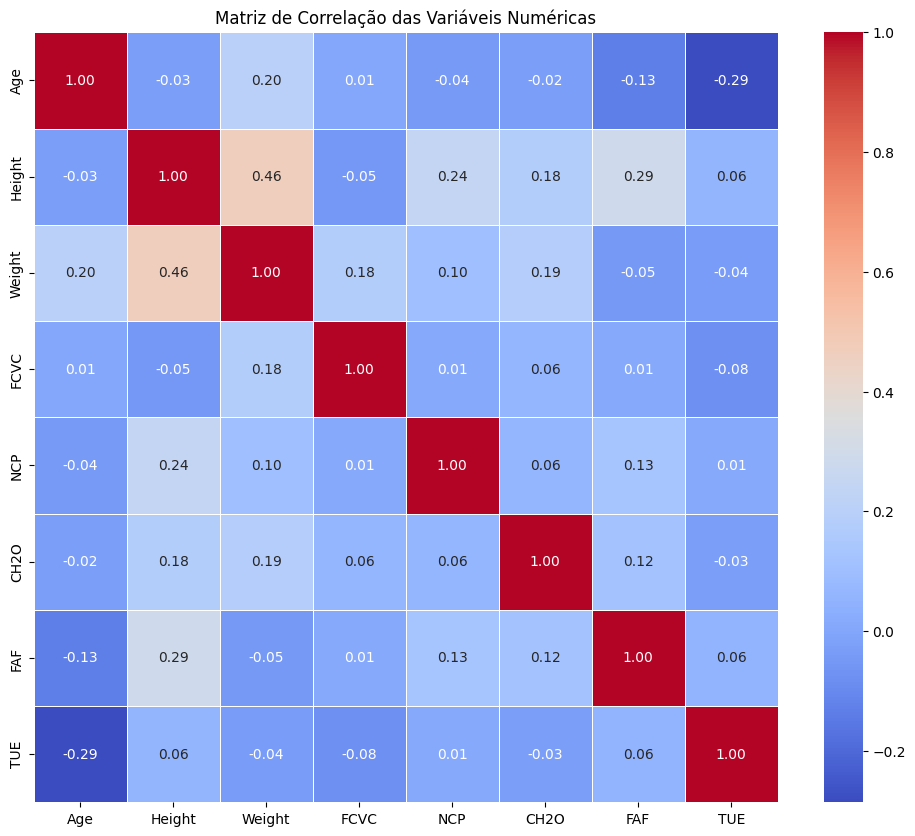

In [4]:
if 'df' in locals():
    plt.figure(figsize=(12, 10))
    # Selecionando apenas as colunas numéricas para a correlação
    numeric_df = df.select_dtypes(include=[np.number])
    correlation_matrix = numeric_df.corr()

    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlação das Variáveis Numéricas')
    plt.show()

### Treinamento do Modelo
####4º Etapa
Utilizei o Random Forest para buscar uma assertividade acima de 75%.

In [5]:
if 'X_train' in locals():
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f'Acurácia obtida: {acc:.2%}')
    print('\nRelatório de Classificação:')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Salvar o modelo  para o deploy no Streamlit
    joblib.dump(model, 'modelo_obesidade.pkl')
    joblib.dump(le, 'label_encoder.pkl')
    joblib.dump(X_encoded.columns.tolist(), 'features_columns.pkl')
    print('\nModelo e artefatos salvos com sucesso!')

Acurácia obtida: 93.14%

Relatório de Classificação:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.96      0.98        54
      Normal_Weight       0.79      0.86      0.83        58
     Obesity_Type_I       0.93      0.97      0.95        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.86      0.84      0.85        58
Overweight_Level_II       0.95      0.90      0.92        58

           accuracy                           0.93       423
          macro avg       0.93      0.93      0.93       423
       weighted avg       0.93      0.93      0.93       423


Modelo e artefatos salvos com sucesso!


### Relatório de Classificação Detalhado
####5º Etapa
Nesta seção, avaliamos o desempenho do modelo para cada classe específica.

In [6]:
from sklearn.metrics import classification_report

if 'y_test' in locals() and 'y_pred' in locals():
    report = classification_report(y_test, y_pred, target_names=le.classes_)
    print("Relatório de Classificação Detalhado:")
    print(report)
else:
    print("As variáveis y_test ou y_pred não foram encontradas. Certifique-se de que a célula de treinamento foi executada.")

Relatório de Classificação Detalhado:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.96      0.98        54
      Normal_Weight       0.79      0.86      0.83        58
     Obesity_Type_I       0.93      0.97      0.95        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.86      0.84      0.85        58
Overweight_Level_II       0.95      0.90      0.92        58

           accuracy                           0.93       423
          macro avg       0.93      0.93      0.93       423
       weighted avg       0.93      0.93      0.93       423



### Geração do Aplicativo Streamlit
####6º Etapa
Este código cria o arquivo `Modelo_obesidade_app.py` necessário para o deploy da solução.

In [7]:
%%writefile Modelo_obesidade_app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Configuração da página
st.set_page_config(page_title="Preditor de Obesidade - Tech Challenge", layout="wide")

traducao_classes = {
    'Insufficient_Weight': 'Peso Insuficiente',
    'Normal_Weight': 'Peso Normal',
    'Overweight_Level_I': 'Sobrepeso Nível I',
    'Overweight_Level_II': 'Sobrepeso Nível II',
    'Obesity_Type_I': 'Obesidade Tipo I',
    'Obesity_Type_II': 'Obesidade Tipo II',
    'Obesity_Type_III': 'Obesidade Tipo III'
}

@st.cache_resource
def load_artifacts():
    model = joblib.load('modelo_obesidade.pkl')
    le = joblib.load('label_encoder.pkl')
    features = joblib.load('features_columns.pkl')
    return model, le, features

try:
    model, le, features = load_artifacts()
    st.title("⚕  Sistema de Auxílio ao Diagnóstico: Obesidade")
    st.markdown("--- ")

    col1, col2, col3 = st.columns(3)
    with col1:
        st.subheader("Dados Demográficos")
        gender = st.selectbox("Gênero", ["Masculino", "Feminino"])
        age = st.number_input("Idade", min_value=1, max_value=120, value=25)
        height = st.number_input("Altura (m)", min_value=0.5, max_value=2.5, value=1.70)
        weight = st.number_input("Peso (kg)", min_value=10, max_value=300, value=70)
    with col2:
        st.subheader("Hábitos Alimentares")
        family_history = st.selectbox("Histórico Familiar de Obesidade?", ["Sim", "Não"])
        favc = st.selectbox("Consome comida rica em calorias frequentemente?", ["Sim", "Não"])
        fcvc = st.slider("Frequéncia de consumo de vegetais (1-3)", 1, 3, 2)
        ncp = st.slider("Número de refeições principais por dia", 1, 4, 3)
        caec = st.selectbox("Consumo de alimentos entre as refeições", ["Às vezes", "Frequentemente", "Sempre", "Não"])
        smoke = st.selectbox("Fumante?", ["Sim", "Não"])
        ch2o = st.slider("Consumo diário de água (litros)", 1, 3, 2)
    with col3:
        st.subheader("Estilo de Vida")
        scc = st.selectbox("Monitora consumo de calorias?", ["Sim", "Não"])
        faf = st.slider("Atividade física semanal (0-3)", 0, 3, 1)
        tue = st.slider("Tempo de uso de eletrônicos (0-2)", 0, 2, 0)
        calc = st.selectbox("Consumo de álcool", ["Não", "Às vezes", "Frequentemente", "Sempre"])
        mtrans = st.selectbox("Meio de transporte principal", ["Transporte Pùblico", "Automóvel", "Caminhada", "Motocicleta", "Bicicleta"])

    if st.button("Realizar Predição"):
        map_sim_nao = {"Sim": "yes", "Não": "no"}
        map_caec = {"Às vezes": "Sometimes", "Frequentemente": "Frequently", "Sempre": "Always", "Não": "no"}
        map_calc = {"Não": "no", "Às vezes": "Sometimes", "Frequentemente": "Frequently", "Sempre": "Always"}
        map_trans = {"Transporte Pùblico": "Public_Transportation", "Automóvel": "Automobile", "Caminhada": "Walking", "Motocicleta": "Motorbike", "Bicicleta": "Bike"}
        map_gender = {"Masculino": "Male", "Feminino": "Female"}

        input_dict = {
            'Gender': map_gender[gender],
            'Age': age,
            'Height': height,
            'Weight': weight,
            'family_history_with_overweight': map_sim_nao[family_history],
            'FAVC': map_sim_nao[favc],
            'FCVC': fcvc,
            'NCP': ncp,
            'CAEC': map_caec[caec],
            'SMOKE': map_sim_nao[smoke],
            'CH2O': ch2o,
            'SCC': map_sim_nao[scc],
            'FAF': faf,
            'TUE': tue,
            'CALC': map_calc[calc],
            'MTRANS': map_trans[mtrans]
        }

        input_df = pd.DataFrame([input_dict])
        input_encoded = pd.get_dummies(input_df).reindex(columns=features, fill_value=0)

        prediction = model.predict(input_encoded)
        raw_label = le.inverse_transform(prediction)[0]
        result_label = traducao_classes.get(raw_label, raw_label)

        st.success(f"### Diagnóstico Sugerido: {result_label}")

        report_text = f"""RELATÓRIO DE DIAGNÓSTICO PREVENTIVO
-----------------------------------
Dados do Paciente:
- Idade: {age} anos
- Gênero: {gender}
- Peso/Altura: {weight}kg / {height}m

Resultado da Análise:
- Diagnóstico Sugerido: {result_label}

Observações de Hábitos:
- Histórico Familiar: {family_history}
- Atividade Física (0-3): {faf}
- Consumo de Água (1-3): {ch2o}
- Consumo de Vegetais (1-3): {fcvc}
-----------------------------------
Gerado por: Sistema IA Obesidade Tech Challenge
"""
        st.download_button(
            label="⏬ Baixar Relatório do Diagnóstico",
            data=report_text,
            file_name=f"relatorio_diagnostico_{age}anos.txt",
            mime="text/plain"
        )

except Exception as e:
    st.error(f"Erro ao processar: {e}")

Writing Modelo_obesidade_app.py


### Matriz de Confusão
Visualização gráfica dos erros e acertos do modelo para cada categoria.

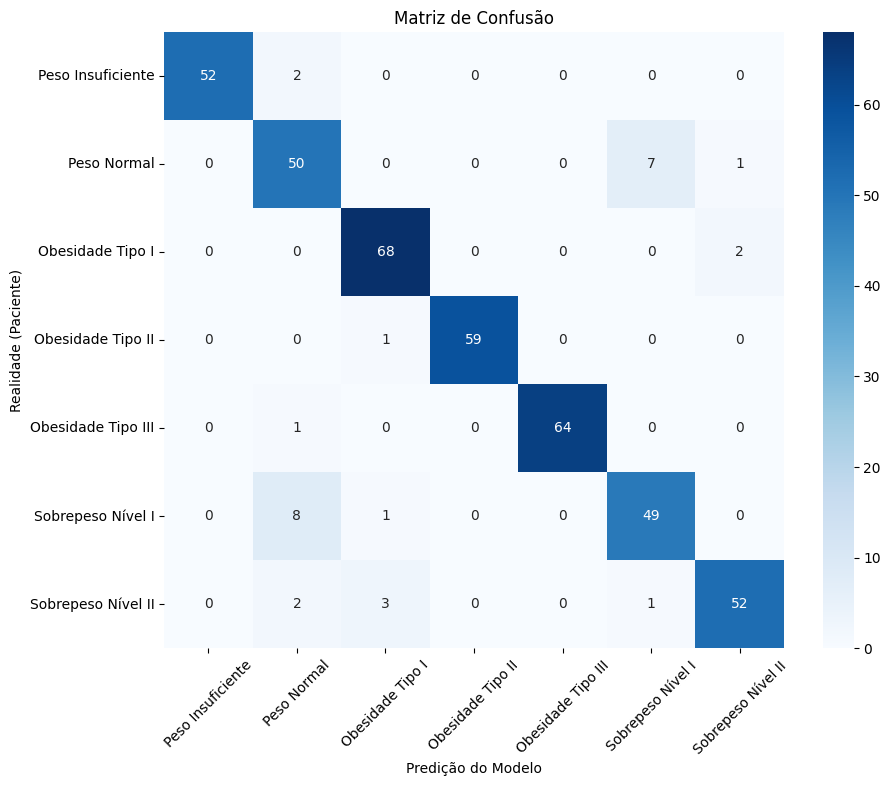

In [8]:
from sklearn.metrics import confusion_matrix

# Definindo o dicionário de tradução para corrigir o NameError
traducao_classes = {
    'Insufficient_Weight': 'Peso Insuficiente',
    'Normal_Weight': 'Peso Normal',
    'Overweight_Level_I': 'Sobrepeso Nível I',
    'Overweight_Level_II': 'Sobrepeso Nível II',
    'Obesity_Type_I': 'Obesidade Tipo I',
    'Obesity_Type_II': 'Obesidade Tipo II',
    'Obesity_Type_III': 'Obesidade Tipo III'
}

if 'y_test' in locals() and 'y_pred' in locals():
    cm = confusion_matrix(y_test, y_pred)
    # Traduzindo as classes para o gráfico da matriz de confusão
    classes_pt = [traducao_classes.get(c, c) for c in le.classes_]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes_pt, yticklabels=classes_pt)
    plt.title('Matriz de Confusão')
    plt.ylabel('Realidade (Paciente)')
    plt.xlabel('Predição do Modelo')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Variáveis de teste ou predição não encontradas.")

Fim das etapas do modelo e deploy

# iniciando o dashboard

## 📊 Dashboard de Insights Clínicos (Visão 360º)
Nesta seção, consolidamos os dados comportamentais e fisiológicos para fornecer uma visão geral dos pacientes à equipe médica.

### 📈 Dashboard de Perfil Demográfico e Gênero
Análise focada em como o gênero influencia as categorias de peso observadas.

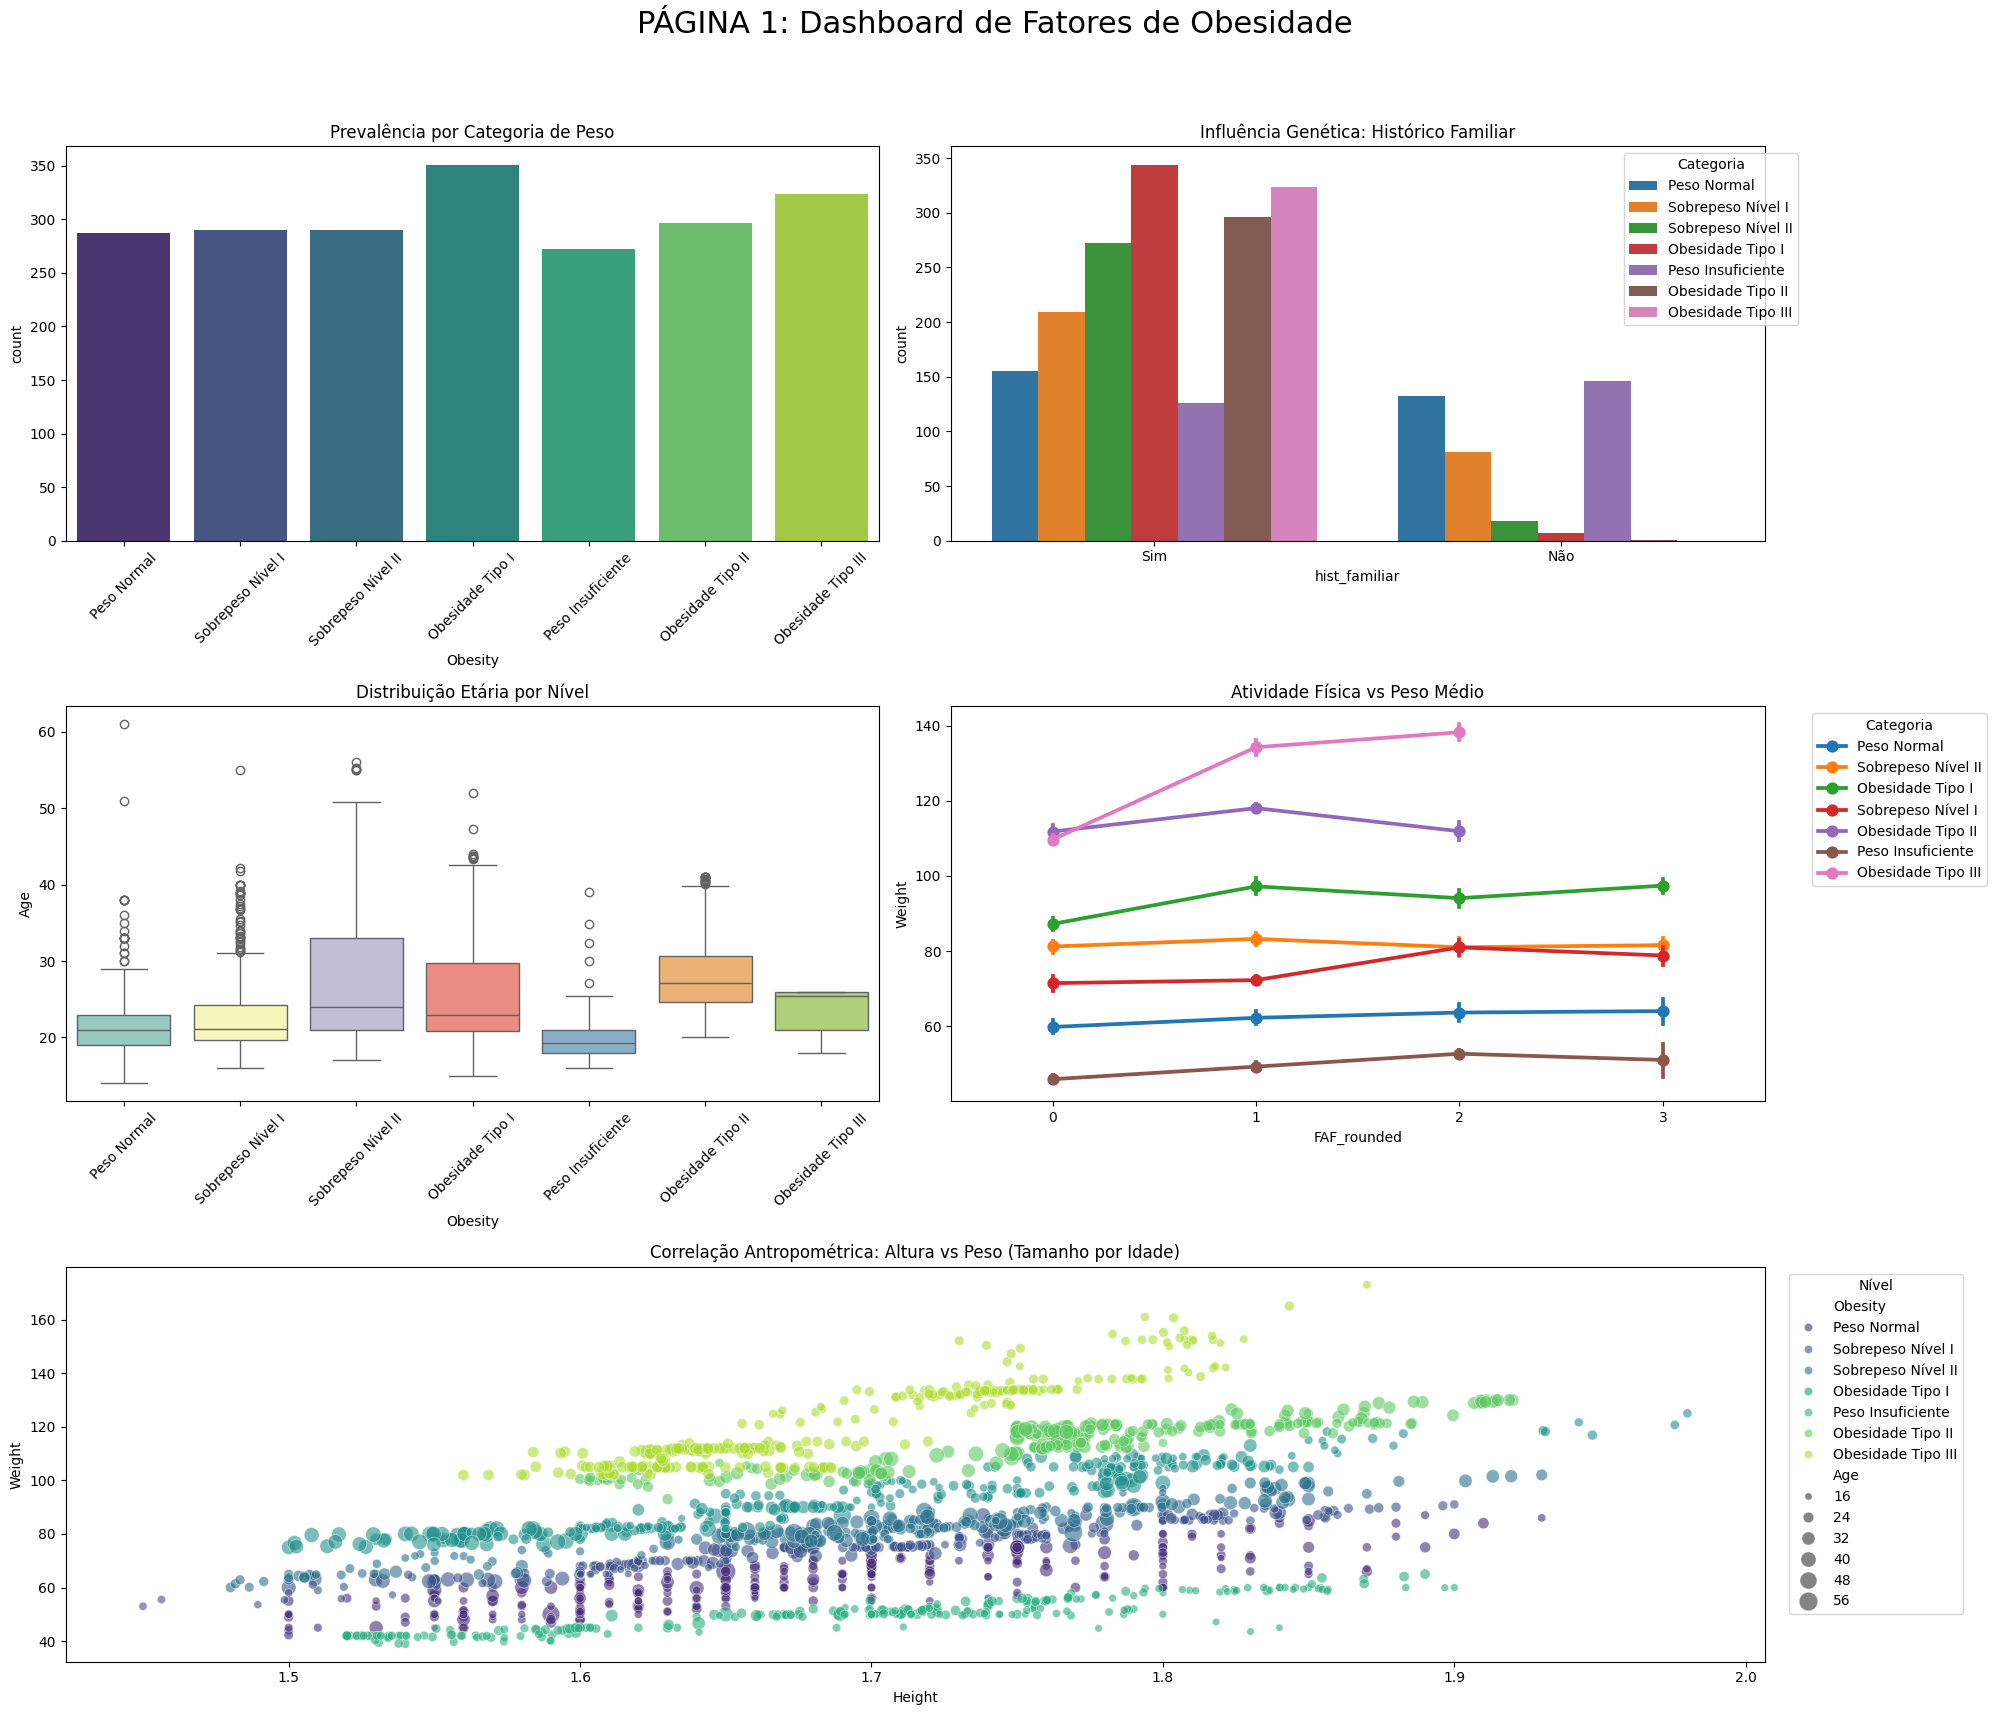

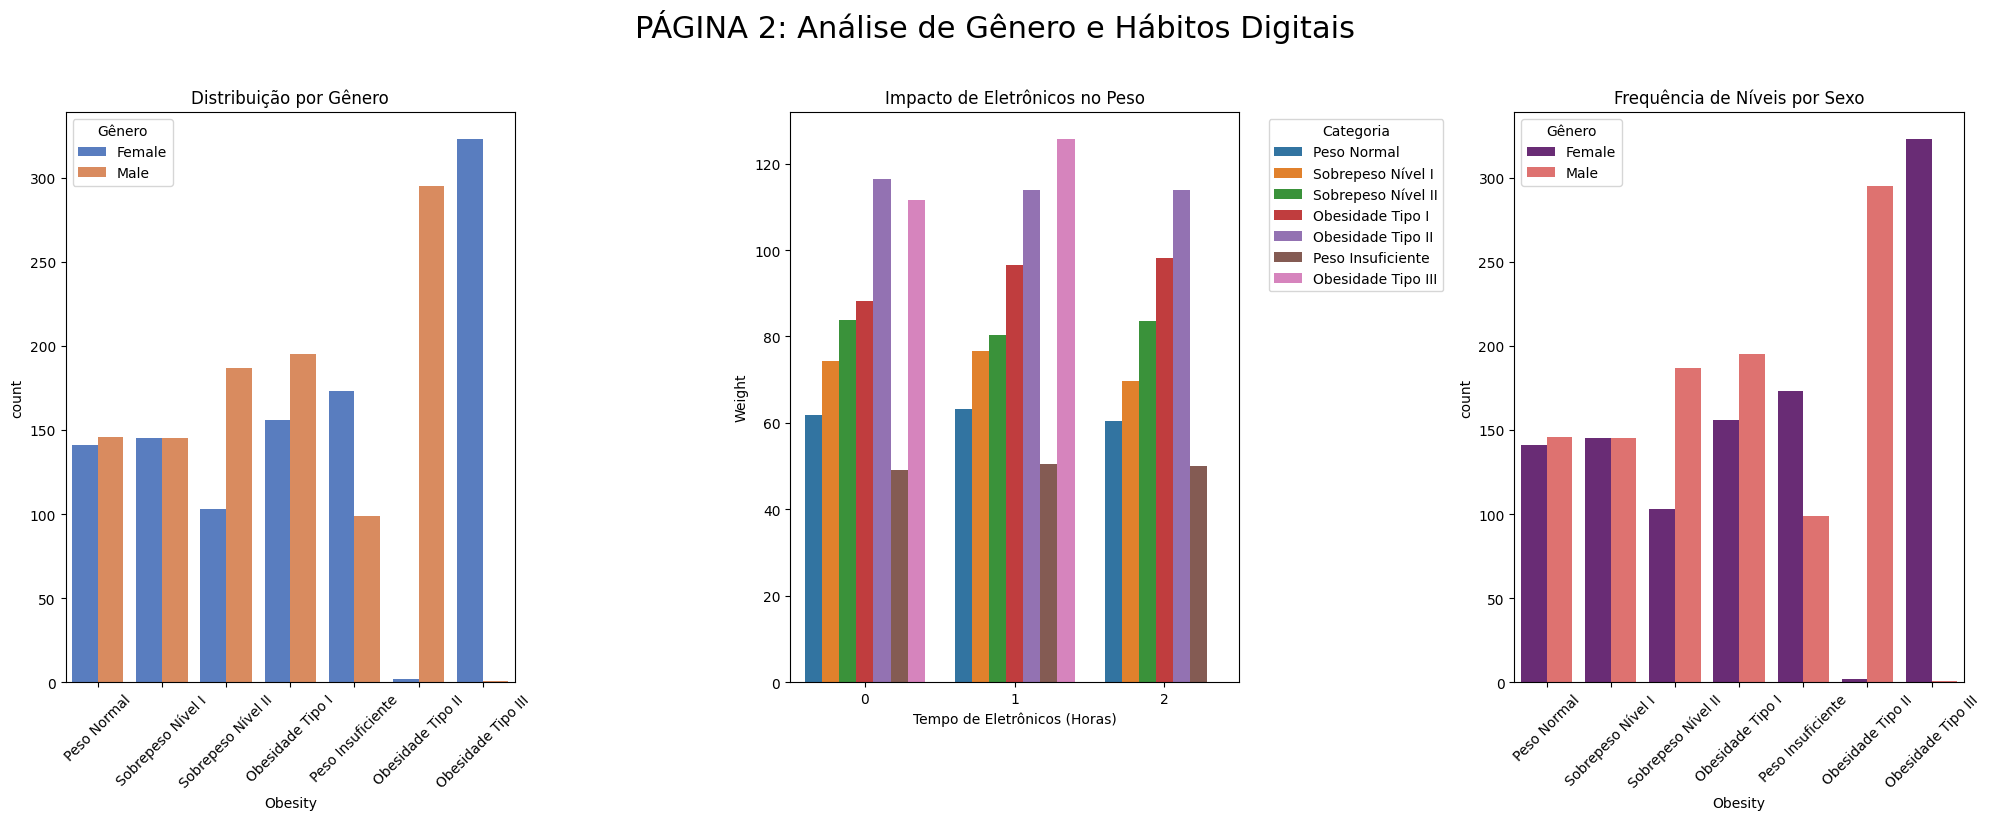

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals():
    # --- PREPARAÇÃO DE DADOS (Unificada) ---
    target_col = 'Obesity' if 'Obesity' in df.columns else 'Obesity_level'
    traducao_classes = {
        'Insufficient_Weight': 'Peso Insuficiente',
        'Normal_Weight': 'Peso Normal',
        'Overweight_Level_I': 'Sobrepeso Nível I',
        'Overweight_Level_II': 'Sobrepeso Nível II',
        'Obesity_Type_I': 'Obesidade Tipo I',
        'Obesity_Type_II': 'Obesidade Tipo II',
        'Obesity_Type_III': 'Obesidade Tipo III'
    }

    df_dash = df.copy()
    df_dash[target_col] = df_dash[target_col].map(traducao_classes)
    df_dash['hist_familiar'] = df_dash['family_history'].map({'yes': 'Sim', 'no': 'Não'})
    df_dash['FAF_rounded'] = df_dash['FAF'].round()
    df_dash['TUE_rounded'] = df_dash['TUE'].round()

    # =========================================================
    # PÁGINA 1: DASHBOARD DE FATORES GERAIS E DISPERSÃO
    # =========================================================
    fig1 = plt.figure(figsize=(20, 18))
    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    plt.suptitle('PÁGINA 1: Dashboard de Fatores de Obesidade', fontsize=22, y=0.98)

    # 1. Distribuição de Classes
    plt.subplot(3, 2, 1)
    sns.countplot(data=df_dash, x=target_col, hue=target_col, palette='viridis', legend=False)
    plt.title('Prevalência por Categoria de Peso')
    plt.xticks(rotation=45)

    # 2. Histórico Familiar
    plt.subplot(3, 2, 2)
    sns.countplot(data=df_dash, x='hist_familiar', hue=target_col)
    plt.title('Influência Genética: Histórico Familiar')
    plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1))

    # 3. Idade e Obesidade
    plt.subplot(3, 2, 3)
    sns.boxplot(data=df_dash, x=target_col, y='Age', palette='Set3', hue=target_col, legend=False)
    plt.title('Distribuição Etária por Nível')
    plt.xticks(rotation=45)

    # 4. Atividade Física
    plt.subplot(3, 2, 4)
    sns.pointplot(data=df_dash, x='FAF_rounded', y='Weight', hue=target_col, markers='o')
    plt.title('Atividade Física vs Peso Médio')
    plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1))

    # 5. Gráfico de Dispersão (Ocupando a base da Página 1)
    plt.subplot(3, 1, 3)
    sns.scatterplot(data=df_dash, x='Height', y='Weight', hue=target_col, size='Age', sizes=(20, 200), alpha=0.6, palette='viridis')
    plt.title('Correlação Antropométrica: Altura vs Peso (Tamanho por Idade)')
    plt.legend(title='Nível', bbox_to_anchor=(1.01, 1))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # =========================================================
    # PÁGINA 2: ANÁLISE DE GÊNERO E Perfil Demográfico
    # =========================================================
    plt.figure(figsize=(20, 8))
    plt.suptitle('PÁGINA 2: Análise de Gênero e Hábitos Digitais', fontsize=22, y=1.02)

    # 1. Gênero (Distribuição Geral)
    plt.subplot(1, 3, 1)
    sns.countplot(data=df_dash, x=target_col, hue='Gender', palette='muted')
    plt.title('Distribuição por Gênero')
    plt.xticks(rotation=45)
    plt.legend(title='Gênero')

    # 2. Uso de Tecnologia
    plt.subplot(1, 3, 2)
    sns.barplot(data=df_dash, x='TUE_rounded', y='Weight', hue=target_col, errorbar=None)
    plt.title('Impacto de Eletrônicos no Peso')
    plt.xlabel('Tempo de Eletrônicos (Horas)')
    plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1))

    # 3. Categorias de Obesidade por Gênero (Variação de Cores)
    plt.subplot(1, 3, 3)
    sns.countplot(data=df_dash, x=target_col, hue='Gender', palette='magma')
    plt.title('Frequência de Níveis por Sexo')
    plt.xticks(rotation=45)
    plt.legend(title='Gênero')

    plt.tight_layout()
    plt.show()

### 📊 Dashboard Interativo (Versão Plotly)
Utilizando Plotly para permitir zoom, filtros por legenda e visualização dinâmica dos dados.

In [10]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if 'df' in locals():
    # Preparação dos dados com mapeamento para português
    df_plotly = df.copy()
    target_col = 'Obesity' if 'Obesity' in df.columns else 'Obesity_level'

    # Mapeamento de valores categóricos para português
    map_sim_nao = {'yes': 'Sim', 'no': 'Não'}
    map_genero = {'Male': 'Masculino', 'Female': 'Feminino'}

    df_plotly['Nível'] = df_plotly[target_col].map(traducao_classes)
    df_plotly['Gender'] = df_plotly['Gender'].map(map_genero)
    df_plotly['family_history'] = df_plotly['family_history'].map(map_sim_nao)

    # Tradução de nomes de colunas para o Tooltip e Eixos
    df_plotly = df_plotly.rename(columns={
        'Gender': 'Gênero',
        'Age': 'Idade',
        'Height': 'Altura',
        'Weight': 'Peso',
        'family_history': 'Histórico Familiar'
    })

    # 1. Distribuição de Classes (Interativo)
    fig_dist = px.histogram(df_plotly, x="Nível", color="Gênero",
                            title="Distribuição por Categoria e Gênero",
                            barmode="group",
                            labels={'count': 'Frequência'},
                            color_discrete_sequence=px.colors.qualitative.Safe)
    fig_dist.show()

    # 2. Correlação Altura vs Peso com filtros
    fig_scatter = px.scatter(df_plotly, x="Altura", y="Peso",
                             color="Nível", size="Idade",
                             hover_data=['Gênero', 'Histórico Familiar'],
                             title="Dispersão: Altura vs Peso (Tamanho por Idade)",
                             labels={'Altura': 'Altura (m)', 'Peso': 'Peso (kg)'})
    fig_scatter.update_layout(legend_title_text='Clique na legenda para filtrar:')
    fig_scatter.show()

    # 3. Boxplot de Idade
    fig_age = px.box(df_plotly, x="Nível", y="Idade", color="Nível",
                     title="Distribuição de Idade por Categoria de Peso",
                     labels={'Idade': 'Idade (anos)'})
    fig_age.show()